# Automatic generation of masks with SAM2

Run this notebook from within the SAM2 directory where their other notebooks are located.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
import sys
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.build_sam import build_sam2
import json
import pickle

In [2]:
# specify a gpu to use
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [ ]:
#    Constants
# -------------------------------------------------------------------- #

# acceptable image file extensions
IMG_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.TIF']

# SAM2 constants
SAM2_CHECKPOINT = "/home/username/Models/sam2.1_hiera_large.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"
DEVICE = "cuda"

STUDY_FOLDER = '/home/username/Code/SAM2/pv_results/segmentation/' # make sure this folder exists
EXPERIMENT_DESCRIPTION = 'Running SAM2 custom-w2 params on the 1200 images with ground truth masks available.'
EXPERIMENT_ID = '003 custom-w2'
# create this folder if it doesn't exist
os.makedirs(Path(STUDY_FOLDER, EXPERIMENT_ID), exist_ok=True)

IMAGES_FOLDER = '/home/username/Data/Microscopy/BBBC005/BBBC005_v1_ground_truth/BBBC005_v1_ground_truth' # this will be used to synthesize the actual file names, because this folder is the ground truth folder

# Results file
OUTPUT_FILE_PATH = Path(STUDY_FOLDER, EXPERIMENT_ID, 'output.jsonl')

## Define methods here

In [4]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

## Import images

In [5]:
# read images from the folder
images = []
# labels = []
filenames = []
for file in os.listdir(IMAGES_FOLDER):
    # we need to replace the 'BBBC005_v1_ground_truth/BBBC005_v1_ground_truth' with 'BBBC005_v1_images' to get the actual image
    original_file_path = os.path.join(IMAGES_FOLDER, file)
    new_file_path = original_file_path.replace('BBBC005_v1_ground_truth/BBBC005_v1_ground_truth', 'BBBC005_v1_images')
    if any([file.endswith(ext) for ext in IMG_EXTENSIONS]):
        image = cv2.imread(new_file_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
    # get the labels from the filename. The label is the number inside the "_C<number>_" string
    # label = file.split("_")[2].strip("C")
    # labels.append(label)
    filenames.append(Path(file).name)

print(f"Loaded {len(filenames)} images")

Loaded 1200 images


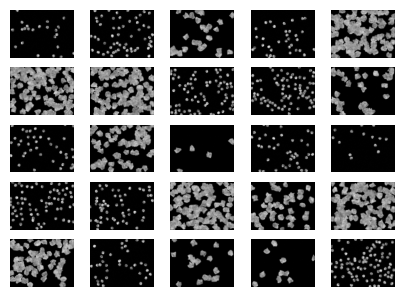

In [6]:
# plot the first 25 images in a grid
fig, axs = plt.subplots(5, 5, figsize=(5, 3.6))
for i, ax in enumerate(axs.flatten()):
    if i < 25:
        ax.imshow(images[i])
    ax.axis('off')
plt.show()

## Initialize sam2 object

In [7]:
sam2_model = build_sam2(SAM2_CONFIG, SAM2_CHECKPOINT, device=DEVICE)

## Mask generation

In [8]:
# are you using default or custom generator?
USE_CUSTOM_GENERATOR = True

if USE_CUSTOM_GENERATOR:
    mask_generator = SAM2AutomaticMaskGenerator(
    model = sam2_model,
    points_per_side = 32,
    points_per_batch = 64,
    pred_iou_thresh = 0.7,
    stability_score_thresh = 0.9,
    stability_score_offset = 1.0,
    box_nms_thresh = 0.9,
    crop_n_layers = 0,
    crop_nms_thresh = 0.7,
    crop_overlap_ratio = 0.05, # Sets the degree to which crops overlap. In the first crop layer, crops will overlap by this fraction of the image length. Later layers with more crops scale down this overlap. Default 512 / 1500
    crop_n_points_downscale_factor = 1,
    point_grids = None,
    min_mask_region_area = 0, # If >0, postprocessing will be applied to remove disconnected regions and holes in masks with area smaller than min_mask_region_area. Requires opencv.
    # output_mode = "binary_mask"
)
else:
    mask_generator = SAM2AutomaticMaskGenerator(sam2_model)

In [9]:
# initialize a list to contain the masks
masks = []

In [10]:
# improved binary mask generation function from old SAM file
def show_anns_binary(anns):
    # don't run if no masks are found
    if len(anns) == 0:
        return np.zeros((520, 696, 3)), 0  # return empty 3-channel image and count
    
    # sort the anns in the descending order of area
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    # remove any mask that are at least 25% of the image area
    # calculate the area of the masks
    img_area = sorted_anns[0]['segmentation'].shape[0] * sorted_anns[0]['segmentation'].shape[1]
    sorted_anns = [ann for ann in sorted_anns if ann['area'] < 0.25 * img_area]

    # note that all masks have the same shape
    # also note that the source images have 3 channels, so I am going to create a 3 channel mask
    # create a blank image to hold the masks
    img = np.zeros((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 3)) # binary black image

    # for each mask, set each pixel value in the blank image to 1
    for ann in sorted_anns:
        m = ann['segmentation'] # each m has the same shape as that of the image, for example (520, 696)
        img[m] = 1

    return img, len(sorted_anns)  # return both image and filtered count

In [11]:
from scipy.spatial.distance import directed_hausdorff
from PIL import Image
import re

# Define comprehensive evaluation metrics
def dice_score(img1, img2):
    return 2*np.sum(img1*img2)/(np.sum(img1) + np.sum(img2))

# let's calculate the f1 score for these two images
def f1_score(img1, img2):
    tp = np.sum(img1*img2)
    fp = np.sum(img1*(1-img2))
    fn = np.sum((1-img1)*img2)
    return tp/(tp + 0.5*(fp + fn))

# get jaccard index
def jaccard_index(img1, img2):
    tp = np.sum(img1*img2)
    fp = np.sum(img1*(1-img2))
    fn = np.sum((1-img1)*img2)
    return tp/(tp + fp + fn)

# calculate hausdorff distance
def hausdorff_distance(img1, img2):
    # both images should be 2D arrays, however our images are 3D arrays... we can average the 3 channels
    img1_2d = np.mean(img1, axis=2)
    img2_2d = np.mean(img2, axis=2)
    return max(directed_hausdorff(img1_2d, img2_2d)[0], directed_hausdorff(img2_2d, img1_2d)[0])

# Simple filename parsing like in the old SAM file
# Extract ground truth cell count from filename (the number inside "_C<number>_" string)
def extract_ground_truth_count(filename):
    return filename.split("_")[2].strip("C")

In [12]:
# create folders for better organization 
Path(STUDY_FOLDER, EXPERIMENT_ID, 'mask_images').mkdir(parents=True, exist_ok=True)
Path(STUDY_FOLDER, EXPERIMENT_ID, 'diff_images').mkdir(parents=True, exist_ok=True)

# Read ground truth images
gt_images = []
gt_filenames = []
for file in os.listdir(IMAGES_FOLDER):
    if any([file.endswith(ext) for ext in IMG_EXTENSIONS]):
        gt_image = cv2.imread(os.path.join(IMAGES_FOLDER, file))
        gt_image = cv2.cvtColor(gt_image, cv2.COLOR_BGR2RGB)
        gt_images.append(gt_image)
        gt_filenames.append(Path(file).name)

print(f"Loaded {len(gt_filenames)} ground truth images")

# Clear the output file for fresh run
if os.path.exists(OUTPUT_FILE_PATH):
    os.remove(OUTPUT_FILE_PATH)

# Generate masks and calculate comprehensive metrics for each image
for img, gt_img, fname, gt_fname in zip(images, gt_images, filenames, gt_filenames):

    m = mask_generator.generate(img)
    masks.append(m)
    
    # Generate 3-channel binary mask using improved function and get filtered count
    mask_img, filtered_count = show_anns_binary(m) 

    # save mask_img to experiment folder using PIL (better than matplotlib)
    Image.fromarray((mask_img*255).astype(np.uint8)).save(Path(STUDY_FOLDER, EXPERIMENT_ID, 'mask_images', fname.split('.')[0]+'.png'))

    print('filename =', fname, 'predicted count =', filtered_count)

    # scale the gt_img to 0-1 to match the mask_img
    gt_img_scaled = gt_img/255

    # Create difference image for visual analysis
    # Red=false positive, Blue=false negative, Green=true positive
    diff_img = np.zeros((mask_img.shape[0], mask_img.shape[1], 3))
    flat_mask_img = np.mean(mask_img, axis=2)
    flat_gt_img = np.mean(gt_img_scaled, axis=2)
    
    diff_img[flat_mask_img == 1] = [1, 0, 0] # red - false positive
    diff_img[flat_gt_img == 1] = [0, 0, 1] # blue - false negative  
    diff_img[(flat_mask_img == 1) & (flat_gt_img == 1)] = [0, 1, 0] # green - true positive
    
    # save diff_img to experiment folder
    Image.fromarray((diff_img*255).astype(np.uint8)).save(Path(STUDY_FOLDER, EXPERIMENT_ID, 'diff_images', fname.split('.')[0]+'.png'))
        
    # Calculate comprehensive evaluation metrics
    d_s = dice_score(mask_img, gt_img_scaled)
    f_s = f1_score(mask_img, gt_img_scaled)  
    j_i = jaccard_index(mask_img, gt_img_scaled)
    h_d = hausdorff_distance(mask_img, gt_img_scaled)
    
    # Create comprehensive results dictionary - matching old SAM file structure exactly
    result_data = {
        'gt_filename': gt_fname,
        'filename': fname,
        'predicted_count': filtered_count,  # Use filtered count, not len(m)
        'dice_score': float(d_s),
        'f1_score': float(f_s),
        'jaccard_index': float(j_i), 
        'hausdorff_distance': float(h_d)
    }
    
    # Save to JSONL file (matching old file format exactly)
    with open(OUTPUT_FILE_PATH, 'a') as f:
        f.write(json.dumps(result_data) + '\n')
        
    # Conditional visualization for debugging extreme cases
    if d_s < 0.3:
        print('filename =', fname, 'dice score =', f'{d_s:.3f}')
        plt.figure(figsize=(8, 6))
        plt.imshow(diff_img)
        plt.title(f'{fname} - Dice: {d_s:.3f}, F1: {f_s:.3f}, Jaccard: {j_i:.3f}')
        plt.axis('off')
        plt.show()
        plt.close()

# save the masks to the experiment folder as a pickle file
masks_file = Path(STUDY_FOLDER, EXPERIMENT_ID, 'masks.pkl')
with open(masks_file, 'wb') as f:
    pickle.dump(masks, f)

# print(f"\nProcessing complete!")
# print(f"Results saved to: {OUTPUT_FILE_PATH}")
# print(f"Mask images saved to: {Path(STUDY_FOLDER, EXPERIMENT_ID, 'mask_images')}")
# print(f"Diff images saved to: {Path(STUDY_FOLDER, EXPERIMENT_ID, 'diff_images')}")

Loaded 1200 ground truth images
filename = SIMCEPImages_A06_C23_F1_s19_w1.TIF predicted count = 25
filename = SIMCEPImages_A14_C57_F1_s05_w1.TIF predicted count = 75
filename = SIMCEPImages_A07_C27_F1_s22_w2.TIF predicted count = 30
filename = SIMCEPImages_A09_C35_F1_s22_w1.TIF predicted count = 42
filename = SIMCEPImages_A22_C91_F1_s24_w2.TIF predicted count = 60
filename = SIMCEPImages_A22_C91_F1_s21_w2.TIF predicted count = 58
filename = SIMCEPImages_A22_C91_F1_s09_w2.TIF predicted count = 52
filename = SIMCEPImages_A18_C74_F1_s03_w1.TIF predicted count = 84
filename = SIMCEPImages_A19_C78_F1_s24_w1.TIF predicted count = 83
filename = SIMCEPImages_A08_C31_F1_s12_w2.TIF predicted count = 23
filename = SIMCEPImages_A10_C40_F1_s22_w1.TIF predicted count = 48
filename = SIMCEPImages_A14_C57_F1_s09_w2.TIF predicted count = 57
filename = SIMCEPImages_A02_C5_F1_s01_w2.TIF predicted count = 5
filename = SIMCEPImages_A10_C40_F1_s06_w1.TIF predicted count = 45
filename = SIMCEPImages_A04_C14_

In [13]:
# calculate overall metrics - minimal output for w1 and w2 images
import pandas as pd

# Read the JSONL output file
results = []
with open(OUTPUT_FILE_PATH, 'r') as f:
    for line in f:
        results.append(json.loads(line.strip()))

df = pd.DataFrame(results)
df['image_type'] = df['filename'].str.extract(r'_w(\d+)\.TIF$')[0].apply(lambda x: f'w{x}')

w1_df = df[df['image_type'] == 'w1']
w2_df = df[df['image_type'] == 'w2']

print("W1 IMAGES:")
print(f"  Dice - Avg: {w1_df['dice_score'].mean():.4f}, Median: {w1_df['dice_score'].median():.4f}")
print(f"  F1   - Avg: {w1_df['f1_score'].mean():.4f}, Median: {w1_df['f1_score'].median():.4f}")
print(f"  Jaccard - Avg: {w1_df['jaccard_index'].mean():.4f}, Median: {w1_df['jaccard_index'].median():.4f}")

print("\nW2 IMAGES:")
print(f"  Dice - Avg: {w2_df['dice_score'].mean():.4f}, Median: {w2_df['dice_score'].median():.4f}")
print(f"  F1   - Avg: {w2_df['f1_score'].mean():.4f}, Median: {w2_df['f1_score'].median():.4f}")
print(f"  Jaccard - Avg: {w2_df['jaccard_index'].mean():.4f}, Median: {w2_df['jaccard_index'].median():.4f}")



W1 IMAGES:
  Dice - Avg: 0.8502, Median: 0.8736
  F1   - Avg: 0.8502, Median: 0.8736
  Jaccard - Avg: 0.7453, Median: 0.7756

W2 IMAGES:
  Dice - Avg: 0.9036, Median: 0.9228
  F1   - Avg: 0.9036, Median: 0.9228
  Jaccard - Avg: 0.8295, Median: 0.8568


## Make sure to save this notebook to the experiment folder